In [ ]:
# this script is used to create masked dataset from images in a folder. It takes images from the dataset root, applies a masking process, and saves the masked images in the masked root. The script allows for selecting specific samples, displaying original and masked pairs, and removing white padding from the plots.

from pathlib import Path

# Sweep folders root
masked_root = Path("/home/tali1/rat_brain_seg/data/masked_sweeps")

# Dataset root that contains original images
dataset_root = Path("/home/tali1/rat_brain_seg/data/dataset_split_70_10_20")

# Sample selection
# Option A: set exact file name (e.g. '10c_slice_4.tif')
# Option B: keep sample_name=None and use sample_index from the sorted candidate list
sample_name = None
sample_index = 0  # 0-based index used when sample_name is None

# Display options
show_pairs = True   # True: original + masked per row, False: original once + masked grid
max_rows = None     # Limit number of sweep folders shown (e.g. 12), or None for all
remove_white_padding = True  # Remove most outer margins/whitespace in plots



In [ ]:
# this script contains utility functions for loading and normalizing images, parsing folder names for labels, and finding original images in the dataset. These functions are used in the visualization script to display original and masked image pairs effectively.
import re
import numpy as np
import matplotlib.pyplot as plt

def load_tif(path: Path):
    """Load a TIF image using tifffile if available, else PIL."""
    try:
        import tifffile as tiff
        img = tiff.imread(str(path))
    except Exception:
        from PIL import Image
        img = np.array(Image.open(path))
    return img

def normalize_for_display(img: np.ndarray):
    """Normalize to [0,1] for grayscale; keep 3 channels for RGB."""
    if img.ndim == 2:
        arr = img.astype(np.float32)
        if arr.max() > arr.min():
            arr = (arr - arr.min()) / (arr.max() - arr.min())
        return arr
    if img.ndim == 3 and img.shape[-1] in (3, 4):
        arr = img.astype(np.float32)
        if arr.max() > 1.0:
            arr = arr / 255.0
        return arr[..., :3]
    arr = np.squeeze(img).astype(np.float32)
    if arr.max() > arr.min():
        arr = (arr - arr.min()) / (arr.max() - arr.min())
    return arr

def parse_label(folder_name: str):
    """Parse folder like ps16_r0.25 into a readable label."""
    m = re.match(r"ps(\d+)_r([0-9.]+)", folder_name)
    if m:
        return f"ps={m.group(1)} r={m.group(2)}"
    return folder_name

def find_original(name: str):
    """Find original image by checking train/val/test images folders."""
    for subset in ("train", "val", "test"):
        p = dataset_root / subset / "images" / name
        if p.exists():
            return p
    # Fallback search
    matches = list(dataset_root.rglob(name))
    return matches[0] if matches else None


In [ ]:
# Gather sweep directories
# this sc
sweep_dirs = sorted([p for p in masked_root.iterdir() if p.is_dir()])
if not sweep_dirs:
    raise FileNotFoundError(f"No sweep folders found under {masked_root}")

# Build candidate list from files common to all sweeps (fallback: first sweep only)
common = None
for d in sweep_dirs:
    files = {p.name for p in d.iterdir() if p.is_file()}
    common = files if common is None else (common & files)

if common:
    candidates = sorted(common)
else:
    candidates = sorted([p.name for p in sweep_dirs[0].iterdir() if p.is_file()])

if not candidates:
    raise FileNotFoundError("No candidate images found in sweep folders")

# Select sample by explicit name or by index
if sample_name is None:
    if sample_index < 0 or sample_index >= len(candidates):
        raise IndexError(f"sample_index={sample_index} is out of range 0..{len(candidates)-1}")
    sample_name = candidates[sample_index]
else:
    if sample_name not in candidates:
        raise FileNotFoundError(f"{sample_name} not found in candidate list")

orig_path = find_original(sample_name)
if orig_path is None:
    raise FileNotFoundError(f"Original image not found for {sample_name}")

orig_img = normalize_for_display(load_tif(orig_path))

if max_rows is not None:
    sweep_dirs = sweep_dirs[:max_rows]

print(f"Using sample: {sample_name}")
print(f"Selected index (0-based): {candidates.index(sample_name)} / {len(candidates)-1}")
print(f"Original: {orig_path}")
print(f"Sweep folders: {len(sweep_dirs)}")



Using sample: 10c_slice_0.tif
Original: /home/tali1/rat_brain_seg/data/dataset_split_70_10_20/train/images/10c_slice_0.tif
Sweep folders: 30


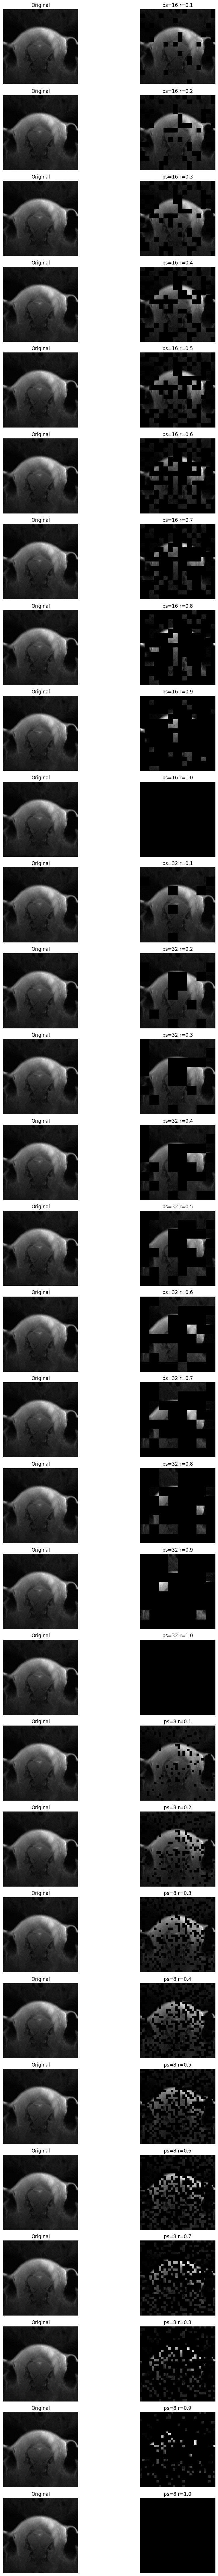

In [ ]:
#  this script is used to create masked dataset from images in a folder. It takes images from the dataset root, applies a masking process, and saves the masked images in the masked root. The script allows for selecting specific samples, displaying original and masked pairs, and removing white padding from the plots.

if show_pairs:
    # One row per sweep: original + masked
    nrows = len(sweep_dirs)
    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(12, 3 * nrows), squeeze=False)

    for i, d in enumerate(sweep_dirs):
        masked_path = d / sample_name
        masked_img = normalize_for_display(load_tif(masked_path))

        axes[i, 0].imshow(orig_img, cmap="gray")
        axes[i, 0].set_title("Original")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(masked_img, cmap="gray")
        axes[i, 1].set_title(parse_label(d.name))
        axes[i, 1].axis("off")

    if remove_white_padding:
        fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0, wspace=0.02, hspace=0.12)
    else:
        plt.tight_layout()
else:
    # Show original once, then masked grid
    cols = 4
    rows = int(np.ceil(len(sweep_dirs) / cols))
    fig = plt.figure(figsize=(4 * cols, 3 * (rows + 1)))

    ax0 = plt.subplot2grid((rows + 1, cols), (0, 0), colspan=cols)
    ax0.imshow(orig_img, cmap="gray")
    ax0.set_title("Original")
    ax0.axis("off")

    for idx, d in enumerate(sweep_dirs):
        r = 1 + idx // cols
        c = idx % cols
        ax = plt.subplot2grid((rows + 1, cols), (r, c))
        masked_path = d / sample_name
        masked_img = normalize_for_display(load_tif(masked_path))
        ax.imshow(masked_img, cmap="gray")
        ax.set_title(parse_label(d.name))
        ax.axis("off")

    if remove_white_padding:
        fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0, wspace=0.02, hspace=0.18)
    else:
        plt.tight_layout()



Sweep: ps32_r0.5
Image file: 10c_slice_0.tif
Image number (1-based in ps32_r0.5): 1
Image index (0-based): 0


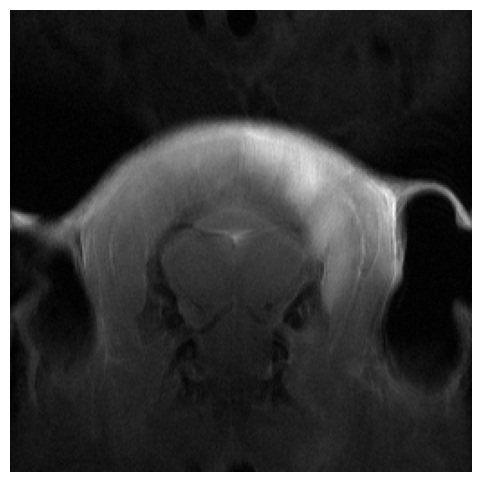

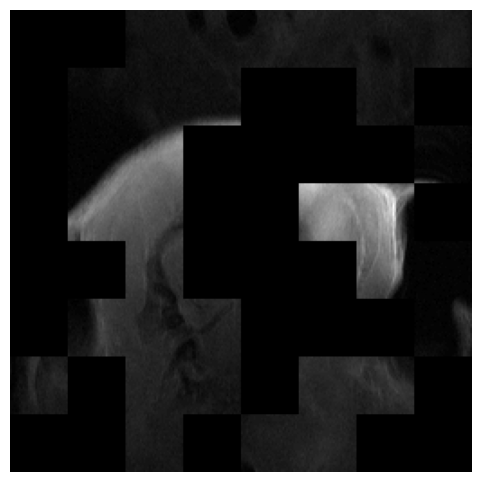

In [15]:
# Extra block: show only ps32_r0.5 original and masked separately
target_sweep = 'ps32_r0.5'
target_dir = masked_root / target_sweep
if not target_dir.exists():
    raise FileNotFoundError(f'Sweep folder not found: {target_dir}')

# Reuse selected sample_name from earlier cells when available
target_name = sample_name if 'sample_name' in globals() and sample_name else None
files = sorted([p.name for p in target_dir.iterdir() if p.is_file()])
if not files:
    raise FileNotFoundError(f'No images in {target_dir}')
if target_name is None or target_name not in files:
    target_name = files[0]

image_idx0 = files.index(target_name)
image_idx1 = image_idx0 + 1

orig_path_local = find_original(target_name)
if orig_path_local is None:
    raise FileNotFoundError(f'Original image not found for {target_name}')
masked_path_local = target_dir / target_name

orig_img_local = normalize_for_display(load_tif(orig_path_local))
masked_img_local = normalize_for_display(load_tif(masked_path_local))

print(f'Sweep: {target_sweep}')
print(f'Image file: {target_name}')
print(f'Image number (1-based in {target_sweep}): {image_idx1}')
print(f'Image index (0-based): {image_idx0}')

plt.figure(figsize=(6, 6))
plt.imshow(orig_img_local, cmap='gray')
# plt.title(f'Original - {target_name}')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(masked_img_local, cmap='gray')
# plt.title(f'Masked ({target_sweep}) - {target_name}')
plt.axis('off')
plt.show()


Sweep folder: /home/tali1/rat_brain_seg/data/masked_sweeps/ps32_r0.5
Selected file: 10c_slice_4.tif
Image number in ps32_r0.5 (1-based): 6
Image index (0-based): 5
Original path: /home/tali1/rat_brain_seg/data/dataset_split_70_10_20/train/images/10c_slice_4.tif
GT mask path (train): /home/tali1/rat_brain_seg/data/dataset_split_70_10_20/train/masks/10c_slice_4.tif


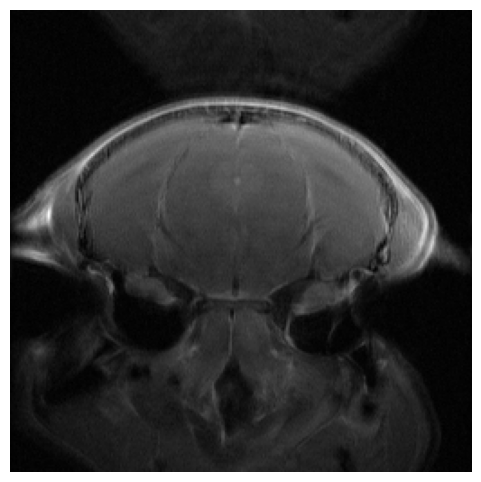

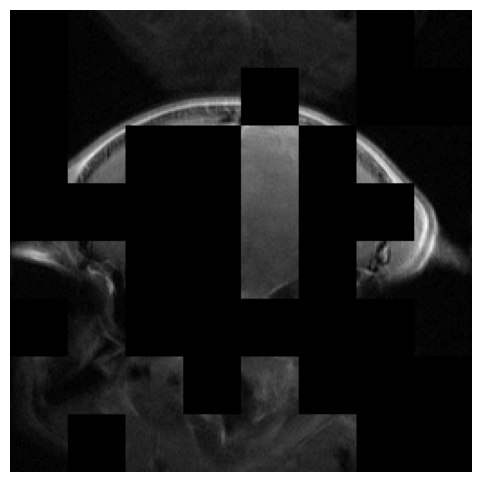

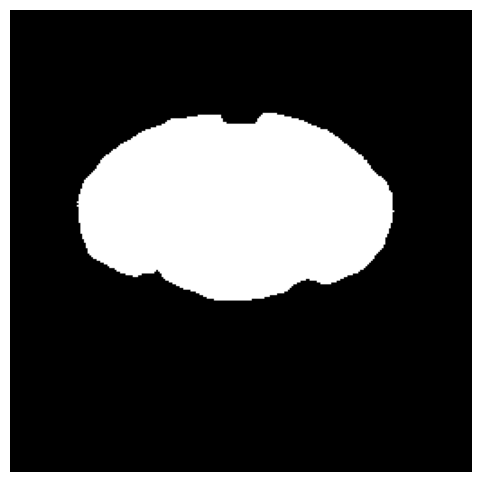

In [26]:
# New block: visualize ps32_r0.5 sample (original, masked, ground truth)
target_sweep = 'ps32_r0.5'
target_dir = masked_root / target_sweep
if not target_dir.exists():
    raise FileNotFoundError(f'Sweep folder not found: {target_dir}')

# Pick image either by exact name or by index in sorted file list
target_name = '10c_slice_4.tif'            # e.g. '10c_slice_4.tif'
target_index = 0              # 0-based index, used when target_name is None

sweep_files = sorted([p.name for p in target_dir.iterdir() if p.is_file()])
if not sweep_files:
    raise FileNotFoundError(f'No image files found in {target_dir}')

if target_name is None:
    if target_index < 0 or target_index >= len(sweep_files):
        raise IndexError(f'target_index={target_index} out of range 0..{len(sweep_files)-1}')
    target_name = sweep_files[target_index]
else:
    if target_name not in sweep_files:
        raise FileNotFoundError(f'{target_name} not found in {target_dir}')

selected_idx0 = sweep_files.index(target_name)
selected_idx1 = selected_idx0 + 1

# Resolve paths for original image and ground-truth mask
orig_path_local = find_original(target_name)
if orig_path_local is None:
    raise FileNotFoundError(f'Original image not found for {target_name}')

def find_mask(name: str):
    for subset in ('train', 'val', 'test'):
        p = dataset_root / subset / 'masks' / name
        if p.exists():
            return p, subset
    matches = list(dataset_root.rglob(name))
    for p in matches:
        if p.parent.name == 'masks':
            return p, p.parent.parent.name
    return None, None

mask_path_local, subset_name = find_mask(target_name)
if mask_path_local is None:
    raise FileNotFoundError(f'Ground-truth mask not found for {target_name}')

masked_path_local = target_dir / target_name

orig_img_local = normalize_for_display(load_tif(orig_path_local))
masked_img_local = normalize_for_display(load_tif(masked_path_local))
gt_mask_local = normalize_for_display(load_tif(mask_path_local))

print(f'Sweep folder: {target_dir}')
print(f'Selected file: {target_name}')
print(f'Image number in {target_sweep} (1-based): {selected_idx1}')
print(f'Image index (0-based): {selected_idx0}')
print(f'Original path: {orig_path_local}')
print(f'GT mask path ({subset_name}): {mask_path_local}')

# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# axes[0].imshow(orig_img_local, cmap='gray')
# axes[0].set_title('Original')
# axes[0].axis('off')

# axes[1].imshow(masked_img_local, cmap='gray')
# axes[1].set_title(f'Masked ({target_sweep})')
# axes[1].axis('off')

# axes[2].imshow(gt_mask_local, cmap='gray')
# axes[2].set_title('Ground Truth Mask')
# axes[2].axis('off')

# fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=0.92, wspace=0.03)
# plt.show()


plt.figure(figsize=(6, 6))
plt.imshow(orig_img_local, cmap='gray')
# plt.title(f'Original - {target_name}')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(masked_img_local, cmap='gray')
# plt.title(f'Masked ({target_sweep}) - {target_name}')
plt.axis('off')
plt.show()


plt.figure(figsize=(6, 6))
plt.imshow(gt_mask_local, cmap='gray')
# plt.title(f'Masked ({target_sweep}) - {target_name}')
plt.axis('off')
plt.show()

